# PyTorch practice /revision

https://docs.pytorch.org/tutorials/beginner/basics/intro.html

In [1]:
import torch
import numpy as np

### Initialising data

* What's the purpose? For when you know the **shape** you need, but you dont know the values yet 
* Use this to initialise random model weights for the first pass 
* use `torch.ones()` or `torch.zeroes()` or `torch.randn()`

In [ ]:
# create tensor from np array 
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
x_data

tensor([[1, 2],
        [3, 4]])

In [ ]:
# load data from existing np array then convert to tensor 
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
x_np

tensor([[1, 2],
        [3, 4]])

In [12]:
# torch.ones_like returns a tensor filled with the scalar value 1, with the same size as input
# applying it to this retains the properties of x_data
x_ones = torch.ones_like(x_data) 
print(f"Ones Tensor: \n {x_ones} \n")

# torch.rand_like returns a tensor filled with random values between 0.0 and 1.0, with the same size as input
# pytorch not implemented for dtype= torch.int, so we specify it as float to avoid error
x_rand = torch.rand_like(x_data, dtype=torch.float) 
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.4079, 0.1558],
        [0.4056, 0.6590]]) 



In [20]:
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.8545, 0.6483, 0.9623],
        [0.6265, 0.7431, 0.7917]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### Attributes of Tensor

In [21]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


In [28]:
tensor = torch.ones(4, 4)
print(tensor)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")

# change second column values from 1 to 0 
tensor[:,1] = 0
print("\n", tensor)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])

 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [ ]:
# all tensors must have the same shape 
# dim=0 means we stack along the rows --> vertically long
# dim=1 means we stack along the columns --> horizontally wide 
t1 = torch.cat([tensor, tensor, tensor], dim=0)
print(t1)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


### Math Operations

In [36]:
# ``tensor.T`` returns the transpose of a tensor
print(tensor)
y1 = tensor.T
print("\nTransposed y1:\n", y1)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

Transposed y1:
 tensor([[1., 1., 1., 1.],
        [0., 0., 0., 0.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


**What does @ mean? --> Multiplication** 

* For two matrices $A (mxn)$ and $B (nxp)$, A @ B results in a new matrix $C(mxp)$
* For a matrix $A (mxn)$ and a vector $v (size n)$, A @ v results in a new vector (size $m$)
* For two vectors $a$ and $b$, a @ b results in a scalar 
* If tensors have more than 2 dimensions, the @ operator will do batched matrix multiplication (ie., multiplication applied to teh last two dimensions, and the leading dimensions are treated as batches)


**Batch Multiplication**

For example, if input is a $(j×1×n×m)$ tensor and other is a $(k×m×p)$ tensor, the batch dimensions are $(j×1)$ and $(k)$, and the matrix dimensions are $(n×m)$ and $(m×p)$. Out will be a $(j×k×n×p)$ tensor.




In [40]:
print(tensor)
y1 = tensor @ tensor
print("\nMultiplied y1:\n", y1)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

Multiplied y1:
 tensor([[3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.],
        [3., 0., 3., 3.]])


Two methods of getting to the same thing: 

* Using the @ operator
* Using the * operator
* Using torch.mul() 
* Using torch.matmul.()

In [45]:
y3 = tensor @ tensor.T
print(y3)

torch.matmul(tensor, tensor.T, out=y3)
print("\n", y3)

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])

 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


In [ ]:
# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)
z3 = tensor.matmul(tensor.T)
z4 = torch.rand_like(tensor)
torch.mul(tensor, tensor.T, out=z4)


print(z1)
print(z2)
print(z3)
print(z4)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
tensor([[1., 0., 1., 1.],
        [0., 0., 0., 0.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


### In-place operations (Discouraged but FYI)

* In-place operations Operations that store the result into the operand are called in-place
* They are denoted by a `_` suffix. For example: `x.copy_(y)`, `x.t_()`, will change `x`
* Not encouraged because although it saves some memory, it causes an immediate loss of history

### Tensors are linked to NumPy

* Tensors on the CPU and NumPy arrays can share their underlying memory locations
* Changing one will change the other; adding numbers to one will immediately add the same numbers to the other 


```
t = torch.ones(5)
n = t.numpy()

# add values, both t, n will change
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

# result
t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]
```

# Datasets, Data Loaders

* `Dataset` stores the samples and their corresponding labels
* `DataLoader` wraps an iterable around the `Dataset` to enable easy access to the samples
* Present in torch.utils: Image, Text, Audio collections


In [68]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Subset
import matplotlib.pyplot as plt

In [ ]:
# https://stackoverflow.com/a/78275278/8770588
torch.cuda.is_available()

False

In [ ]:
# This should tell torch not to load any unnecessary components in RAM
import os
os.environ['CUDA_MODULE_LOADING'] = 'LAZY'

In [66]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26421880/26421880 [00:05<00:00, 4774057.99it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 110608.97it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:04<00:00, 961802.21it/s] 


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 6920601.60it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



 Unfortunately, the datasets.FashionMNIST call always downloads the full dataset — there's no built-in parameter to limit it — but you can immediately subset it in memory and only use that smaller slice for training.

In [ ]:
# Keep 10% of each split
train_subset_size = int(len(training_data) * 0.1)  # 6,000 samples
test_subset_size  = int(len(test_data)     * 0.1)  # 1,000 samples

# ensure no duplicate samples with replace=False
train_indices = np.random.choice(len(training_data), train_subset_size, replace=False)
test_indices  = np.random.choice(len(test_data),     test_subset_size,  replace=False)

training_data = Subset(training_data, train_indices)
test_data     = Subset(test_data,     test_indices)

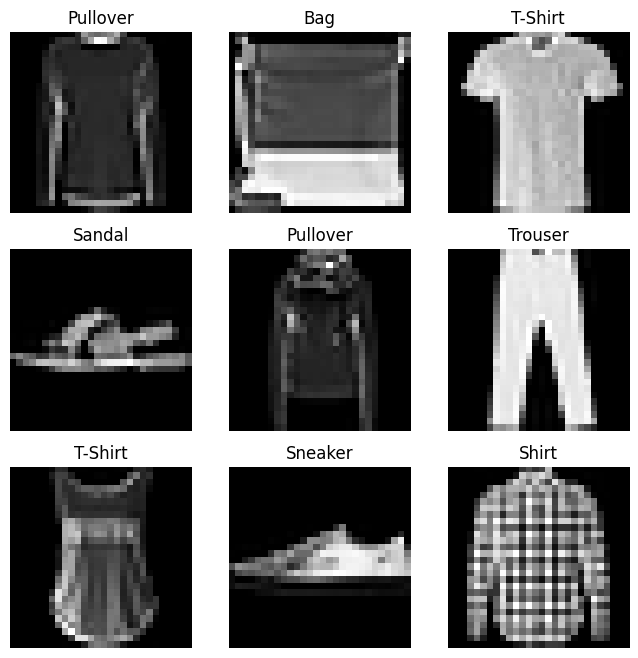

In [ ]:
# plot one item each from fashion dataset
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

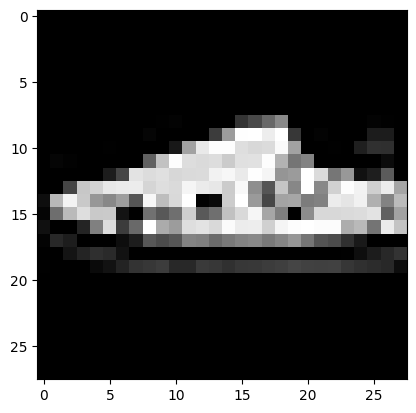

Label: Sneaker


In [ ]:
# suppose i want to print the 3rd image ONLY 
idx = 2 
img, label = training_data[idx]

plt.imshow(img.squeeze(), cmap="gray")
plt.show()
print(f"Label: {labels_map[label]}")

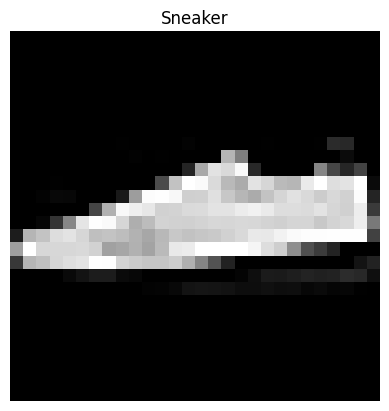

In [91]:
# suppose i want to display a single item at random from a given category (eg., sneakers=7) 
target_labels = {7}

# loop thru index range(len(training_data))
# training_data[i][1] has each item as an (image, label) pair
# if label matches target_labels, the index i is kept 
# add to list named filtered_indices of where all sneakers are located in the dataset
filtered_indices = [i for i in range(len(training_data)) if training_data[i][1] in target_labels]

# pick a position at random within filtered_indices 
# .item() converts it from tensor to a plain python integer
# use integer to lookup actual dataset index from filtered_indices list 
sample_idx = filtered_indices[torch.randint(len(filtered_indices), size=(1,)).item()]

# fetch (img, label) as a pair
img, label = training_data[sample_idx]

# plot 
plt.title(labels_map[label])
plt.axis("off")
plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Custom class Dataset 

* We need to create this class to tell PyTorch how to read our own custom datasets later
* This is because when working with our own messy data, images may be scattered across a folder, or labels are in a separate csv file 
* custom Dataset class lets us feed things into DataLoader for batching, shuffling 


In [ ]:
# our class inherits from PyTorch.Dataset class 
class CustomImageDataset(Dataset):

    # create a constructor to initialize the dataset with annotations file, image directory, and optional transforms
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):

        # csv file should have image filenames in col-0 and their names in col-1 
        self.img_labels = pd.read_csv(annotations_file)

        # folder path to images 
        self.img_dir = img_dir

        # stores optional transformations for IMAGES (eg., normalising, resizing) 
        self.transform = transform

        # stores optional transformations for LABELS (eg., converting string to number)
        self.target_transform = target_transform


    # get num samples in dataset
    def __len__(self):
        return len(self.img_labels)


    # core loading logic 
    def __getitem__(self, idx):

        # full path 
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])

        # load and decode image to tensor based on path 
        image = decode_image(img_path)

        # retrieve label from col 1 of csv fiile 
        label = self.img_labels.iloc[idx, 1]

        # if image or text transformations are specified earlier, apply them here 
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

# Transformations

* Recap: `transform` modifies the dataset 
* Recap: `target_transform` modifies the labels
* Requirements: All features (image, audio, vid, text) must be normalised tensors 
* Requirements: All labels must be one-hot encoded tensors 

In [92]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

In [93]:
ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),   # change image to tensor and normalise values between 0 and 1
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1)) # convert label to one-hot encoding
)

How? (Above)

* A Python Imaging Library (PIL) image is a rasterised image within Python, with key attributes like size (a 2-tuple for width x height), and mode (RBG, greyscale, RGBA for transparency), and format (png, jpeg). This s an instance of the `Image` class 
* `transform = ToTensor()` converts PIL images or numpy `ndarray` into a `FloatTensor` and rescales the image's pixel intensity between [0, 1]
* `target_transform` below creates a zero tensor of size 10 (bc 10 labels) and calls `scatter_` which assigns values on the inidex based on the label `y`

# Build Model

Note: only CPU for this old laptop

In [103]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

What we're doing 

* Defines a new class that inherits from nn.Module, which is PyTorch's base class for all neural networks
* Inheriting from nn.Module gives you built-in functionality like parameter tracking and `.to(device)`
* Init middle layer with random values - 128, 256, 512, 1024 etc. Too small=underfitting, too large=overfitting + slow. 

In [107]:
class NeuralNetwork(nn.Module):
    # define layers in constructor
    def __init__(self):

        # calls the parent nn.Module 
        super().__init__()

        # define a flattened layer: converts each [28x28] image into a contiguous array of 784 pixels, to be fed into a linear layer
        self.flatten = nn.Flatten()

        # define that the next layers are sequential 
        self.linear_relu_stack = nn.Sequential(

            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    # forward pass: 
    def forward(self, x):

        # call the flatten function to convert 28x28 image into 784 pixels
        x = self.flatten(x)

        # pass flatened iinput through full stack of layers above. logts s a tensor of 10 raw scores, one per class
        logits = self.linear_relu_stack(x)

        # use this compute loss or make prediction 
        return logits

device = "cpu"
print(f"Using {device} device")
model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Note: Why call model() instead of calling model.forward()? 

* Because model() goes through nn.Module's __call__() method first, which does other things on top of forwards():
* Calls PyTorch autograd to record operations for backprop later 
* Hooks to run any regiistered pre/post forward hooks for debugging or visualisations 
* Calls training/ eval model checks like Dropout and BatchNorm 

In [ ]:
# create random input tensor with same shape as a single image (1, 28, 28), pass thru model 
X = torch.rand(1, 28, 28, device=device)
logits = model(X)

# get probabilities of labels using softmax 
pred_probab = nn.Softmax(dim=1)(logits)

# get predicted class by finding the index with the maximum value in pred_probab
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([9])


### Putting it all together

* Suppose we do this wthout calling the nn.Module() earlier, instead we type it line by line

In [ ]:
# create 3 random images of size 28x28 as a sample minibatch
input_image = torch.rand(3,28,28)
print(input_image.size())

torch.Size([3, 28, 28])


In [ ]:
# intialise nn.Flatten, then call the flatten() function to convert 28x28 image into 784 pixels
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

torch.Size([3, 784])


In [ ]:
# initialise the Linear() layer as layer1, then call layer1() to take in those 784 pixels and output 20 values as hidden weights
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


In [113]:
# call ReLU over the hidden layer to introduce non-linearity, otherwise the model will just be a linear regression model
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before ReLU: tensor([[ 5.0267e-01, -2.8466e-01,  4.7084e-01,  4.6775e-01,  1.3803e-01,
          2.2463e-01, -4.4581e-02,  3.7387e-01,  1.5889e-01, -2.2964e-01,
         -2.3226e-01, -2.8242e-01, -6.5890e-01,  2.3351e-01, -4.5539e-01,
          2.2978e-02,  3.0379e-01,  1.0048e-01,  3.4108e-01,  3.4917e-02],
        [ 4.5945e-02, -4.5337e-01,  6.9018e-01,  7.4532e-01,  5.7449e-01,
         -1.9744e-01, -2.8633e-01,  7.5179e-01, -1.1858e-01, -1.1783e-01,
         -9.3922e-02, -8.2969e-02, -2.9844e-01,  5.7228e-01, -3.1002e-01,
          1.2905e-01,  4.4039e-01,  5.2061e-02, -3.2861e-02,  2.2503e-01],
        [-1.2299e-04, -3.0681e-01,  5.3809e-01,  3.1302e-01,  1.4919e-01,
          1.2200e-04,  7.3767e-02,  3.5575e-01, -2.5170e-01, -4.4799e-01,
         -1.6947e-01, -1.9509e-01, -7.4837e-01,  6.8678e-02, -1.0152e-01,
          1.5660e-01, -1.6334e-01, -4.6746e-02, -1.0051e-01,  2.9604e-02]],
       grad_fn=<AddmmBackward0>)


After ReLU: tensor([[5.0267e-01, 0.0000e+00, 4.7084e-01, 4.6

In [117]:
# apply softmax as final layer; logits are scaled between 0,1 representing label probabilities for each class

softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)
print(pred_probab)

tensor([[0.0933, 0.0922, 0.0970, 0.1009, 0.1004, 0.0961, 0.1016, 0.1013, 0.1043,
         0.1130]], grad_fn=<SoftmaxBackward0>)


In [ ]:
# take position of highest value
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([9])


In [120]:
print(f"Model structure: {model}\n\n")
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:3]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[-0.0325,  0.0351,  0.0033,  ..., -0.0324,  0.0183, -0.0357],
        [ 0.0154,  0.0177,  0.0269,  ...,  0.0187,  0.0291,  0.0294],
        [ 0.0039,  0.0160, -0.0109,  ...,  0.0091,  0.0002, -0.0316]],
       grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([-0.0310,  0.0188, -0.0324], grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0316,  0.0308,  0.0131,  ...,  0.0307, -0.0039,  0.0154],
        [ 0.0377, -0.0184,  0.0113,  ..., -0.0134,  0.0236,  

# Autograd /Automatic Differentiation

* Input: X 
* Take in parameters W and b (bias)
* X * W + b = z 
* Apply some loss function (eg., cross entropy, CE) to z
* Reshape to fit expected output, y 

In [121]:
x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output

# random params
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)

# z = (x @ W) + b
z = torch.matmul(x, w)+b

# compute loss using CE loss function that combines softmax and cross entropy in one single function, more numerically stable than using them separately
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

In [122]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x128aaa5f0>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x128feba00>


In [ ]:
# call loss.backwards(), then retrieve the gradients of w and b with respect to loss
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.0375, 0.3187, 0.3301],
        [0.0375, 0.3187, 0.3301],
        [0.0375, 0.3187, 0.3301],
        [0.0375, 0.3187, 0.3301],
        [0.0375, 0.3187, 0.3301]])
tensor([0.0375, 0.3187, 0.3301])


Note: 

* To make computations faster in the future, we can disable gradient tracking if we dont need it
* Example: Alr trained model, just want to apply it to inputs 
* Method: `tensor.detach()` 
* Expect: `requires_grad=False` 

# Optimisation

"Training a model is an iterative process; in each iteration the model makes a guess about the output, calculates the error in its guess (loss), collects the derivatives of the error with respect to its parameters (as we saw in the previous section), and optimizes these parameters using gradient descent."

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [ ]:
# repeat of earlier sections:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

In [129]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

### Hyperparameters

* Learning Rate - how much to update models parameters at each batch/epoch. Smaller values yield slow learning speed, while large values may result in unpredictable behavior during training.
* Batch Size - the number of data samples propagated through the network before the parameters are updated
* Number of Epochs - the number of times to iterate over the dataset



In [126]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

### Loss function

* Measures the degree of dissimilarity of obtained result to the target value 
* We want to minimize loss during training 
* Common examples: Mean Square Error (MSE) for regression task loss, Negative Log Likelihood (NLL) for classification loss, Cross Entropy (CE) loss 

In [127]:
# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

### Optimizatiion loop

1. Train Loop 
2. Test loop

What do they do

* The train loop: iterate over dataset, try to converge to optimal parameters
* Test loop: iterate over test set to check if performance is improving 


In [128]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [130]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [131]:
def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [132]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.306288  [   64/60000]
loss: 2.293053  [ 6464/60000]
loss: 2.279512  [12864/60000]
loss: 2.274731  [19264/60000]
loss: 2.251180  [25664/60000]
loss: 2.232057  [32064/60000]
loss: 2.229273  [38464/60000]
loss: 2.204283  [44864/60000]
loss: 2.202626  [51264/60000]
loss: 2.168922  [57664/60000]
Test Error: 
 Accuracy: 52.4%, Avg loss: 2.162134 

Epoch 2
-------------------------------
loss: 2.168585  [   64/60000]
loss: 2.163439  [ 6464/60000]
loss: 2.113696  [12864/60000]
loss: 2.127734  [19264/60000]
loss: 2.081231  [25664/60000]
loss: 2.021128  [32064/60000]
loss: 2.044491  [38464/60000]
loss: 1.973630  [44864/60000]
loss: 1.980141  [51264/60000]
loss: 1.905960  [57664/60000]
Test Error: 
 Accuracy: 59.1%, Avg loss: 1.905286 

Epoch 3
-------------------------------
loss: 1.931199  [   64/60000]
loss: 1.910653  [ 6464/60000]
loss: 1.802007  [12864/60000]
loss: 1.835242  [19264/60000]
loss: 1.741114  [25664/60000]
loss: 1.678166  [32064/600

# PyTorch Cheatsheet / IN SUMMARY 

1. Prediction, make labels
2. Loss calculation to quantify error
3. Gradient calc to find the slope of the loss 
4. Update param (step down slope)
5. Gradient reset (for the next loop)

Functions

1. `y_hat = model(x)`
2. `loss = criterion(y_hat, y)`
3. `loss.backward()`
4. `optimiser.step()`
5. `optimiser.zero_grad()`

Part 1

* Everything is built on np.array aka nn.Tensor, need to learn to create it 

Creation methods for Tensors

* Create from numpy arrays aka `torch.tensor(your_np_array)` 
* Create from a desired shape using `torch.randn()` or `torch.ones()` 
* Create from mimicing an existing tensor using `torch.randn_like(template, dtype=torch.float)`

Part 2 

* What's in a tensor? How do we debug it?
* Every tensor has 3 critcal attributes: Shape, type, device. 

How to debug?

* 90% pytorch errors are shape mismatches, so constantly print the `tensor.shape()`
* Regular tensors will live in CPU, if you've speeded things up it'll be on CUDA (GPU). Access with `.device()`
* Data type - default is `float32`. Model params and biases MUST be floats to be updated so gradient descent can be updated. 
* Autograd = Pytorch built-in gradient calculator. you must set `requires_grad = True`.
* 

### Common Mistakes

* Using * instead of @ for multiplication. We almost always use @. 
* The * gives us an element-wise multiplication for two matrices of exactly the same size ONLY 
* The @ correctly gives us matrix-multiplication, for $(m x n)$ multiplied by $(n x p)$ = $(mxp)$
* Reduction operations like sum, mean, max while specifying the wrong dimension
* dim=0 collapses rows (vertical compression)
* dim=1 collapses columns (horizontal compression)
* We use `argmax()` to find the best performing values - careful again with dimensions 
* Use `torch.argmax.(scores, dim=1)` to get the index position of the best scores in each row 

### More tips

* `torch.gather()`
